# Explore Naive Bayes 

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [3]:
db = pd.read_csv("standardized_crops.csv")
db.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,Apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,Apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,Apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,Apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,Apple


In [ ]:
model = GaussianNB()


X = db.drop("label",axis=1)
y = db['label']


X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train,y_train)

predictions = model.predict(X_test)
print(predictions[:10])

accuracy = accuracy_score(y_test, predictions)
print("Accuracy : ", accuracy)


['Potato (Aloo)' 'Sweet Potato (Shakarkandi)' 'Rapeseed (Sarson)'
 'Sunflower (Surajmukhi)' 'Onion (Pyaaz)' 'Pigeon Peas (Tur/Arhar)'
 'Maize (Corn)' 'Sunflower (Surajmukhi)' 'Garlic (Lehsun)' 'Onion (Pyaaz)']
Accuracy :  0.9992424242424243


In [8]:
print("Training accuracy :-> ", model.score(X_train,y_train))
print("Testing accuracy :-> ", model.score(X_test,y_test))

Training accuracy :->  0.9960197119029568
Testing accuracy :->  0.9992424242424243


In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions,
    zero_division=0
))

                              precision    recall  f1-score   support

                       Apple       1.00      1.00      1.00        20
                      Banana       1.00      1.00      1.00        20
                Barley (Jau)       1.00      1.00      1.00        38
       Bitter Gourd (Karela)       1.00      1.00      1.00         2
           Black Gram (Urad)       1.00      1.00      1.00        20
   Black Pepper (Kali Mirch)       1.00      1.00      1.00        14
        Bottle Gourd (Lauki)       1.00      1.00      1.00         2
  Brinjal (Eggplant/Baingan)       1.00      1.00      1.00         9
         Cabbage (Band Gobi)       1.00      1.00      1.00         4
          Cardamom (Elaichi)       1.00      1.00      1.00         8
    Cauliflower (Phool Gobi)       1.00      1.00      1.00         4
             Chickpea (Gram)       1.00      1.00      1.00        20
           Coconut (Nariyal)       1.00      1.00      1.00        20
                   

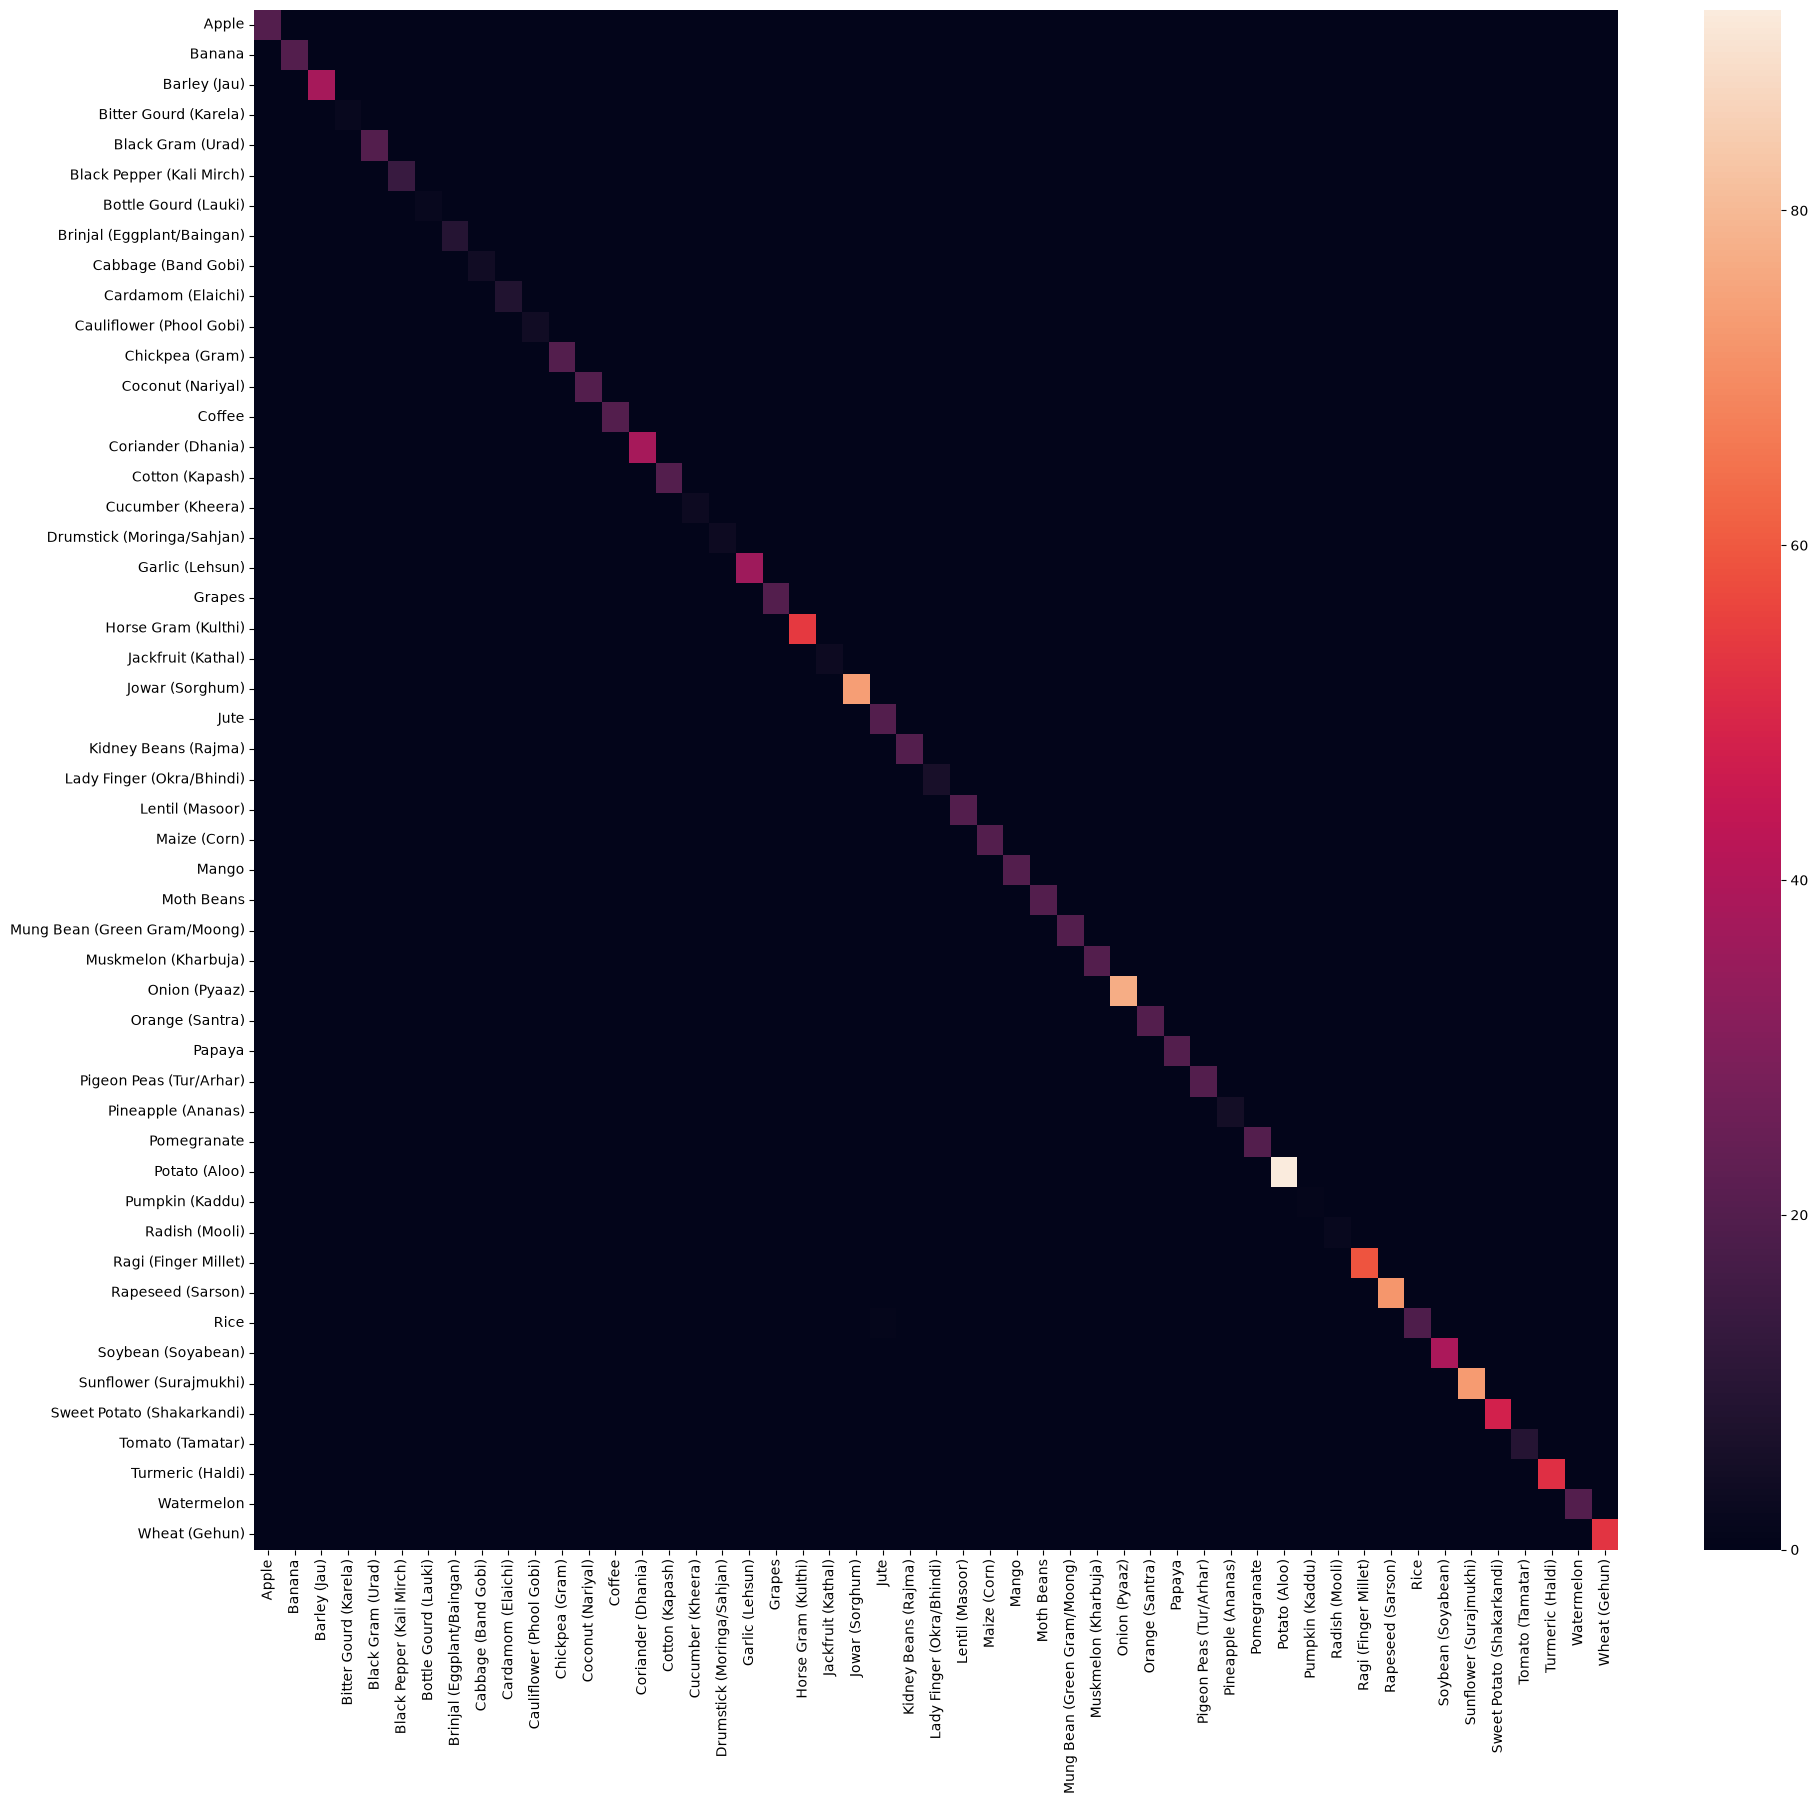

In [19]:
cm = confusion_matrix(y_test,predictions)

plt.figure(figsize=(22, 20))
sns.heatmap(
    cm,
    annot=False,
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.show()